In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load Dataset
df = pd.read_csv("loan_sanction_train.csv")

In [ ]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


### Section 01

In [4]:
# Access the Columns
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
# Seprate Columns based on which element nature
object_data_features = [features for features in df.columns if df[features].dtypes == "O"]
numerical_data_features = [features for features in df.columns if df[features].dtypes != "O"]

print(f"Object Data Features \n\n {object_data_features} \n\nNumerical Data Features \n\n {numerical_data_features}")

Object Data Features 

 ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status'] 

Numerical Data Features 

 ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [6]:
# To Check Null Value of each features
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


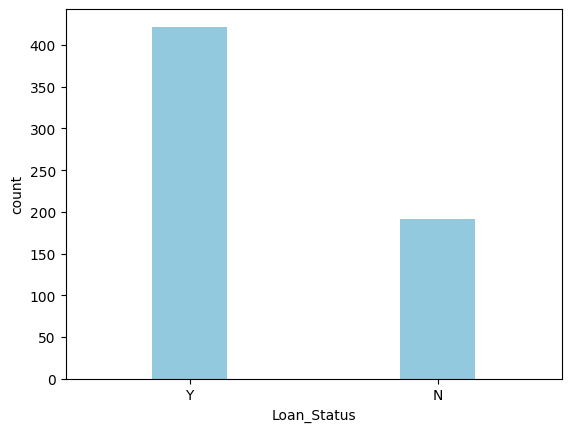

In [7]:
# To Check Given Data Set is Balanced Or Imbalanced
# df.head()
df["Loan_Status"].value_counts()
sns.countplot(x=df["Loan_Status"],color="skyblue",width=0.3)
plt.show()

### **Conclusion 01 :**


1.   Given Dataset Is Imbalanced Dataset.

      Loan_Status	(Value Counts)
        * Y	-- 422
        * N	-- 192

2.   Given Dataset Conatain Many Null values
    * Gender (element data types is  *Object*)     ----	Null Values :-> 13
    * Married (element data types is *Object* )      ----	Null Values :-> 3
    * Dependents (element data types is  *Object*)     ----	Null Values :-> 15
    * Self_Employed (element data types is  *Object*)      ----	Null Values :-> 32

    * LoanAmount (element data types is *Numerical*)     ----	Null Values :-> 22
    * Loan_Amount_Term (element data types is *Numerical*)     ----	Null Values :-> 14
    * Credit_History (element data types is *Numerical*)     ----	Null Values :-> 50
 3. Shape Of Dataset *Rows : 614 and Features : 13*


## Section 2 : Handaling Missing Values

#### Numerical Features

##### LoanAmount (element data types is Numerical) ---- Null Values :-> 22



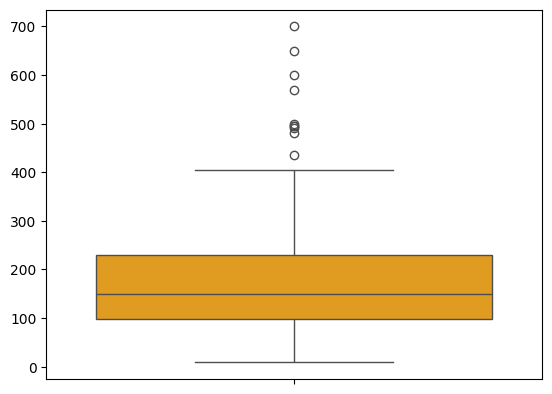

In [9]:
# 614,13
no_of_unique_value_in_loanamount = df["LoanAmount"].unique()
len(no_of_unique_value_in_loanamount)

sns.boxplot(data=no_of_unique_value_in_loanamount,color = "orange")
plt.show()

In [10]:
print(f"Mean : {df['LoanAmount'].mean()} \nMaximum : {df['LoanAmount'].max()}\nMinimum : {df['LoanAmount'].min()},\nMedian : {df['LoanAmount'].median()},\nMode : {df['LoanAmount'].mode()},")

Mean : 146.41216216216216 
Maximum : 700.0
Minimum : 9.0,
Median : 128.0,
Mode : 0    120.0
Name: LoanAmount, dtype: float64,


<Axes: xlabel='LoanAmount', ylabel='Count'>

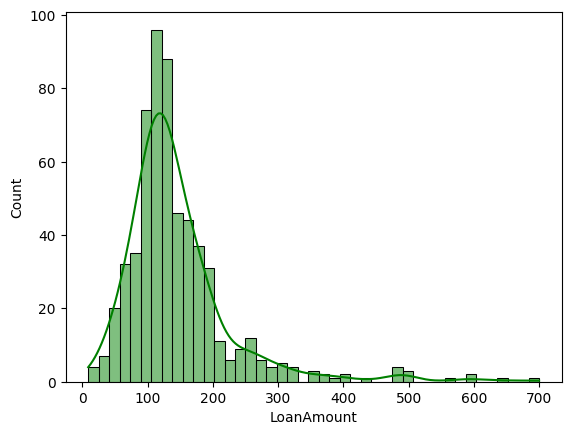

In [11]:
sns.histplot(x=df["LoanAmount"],kde=True,color="green")

###### Decision 01 : In above feature LoanAmount there is many outlier so we can fill the null value by using median of this feature so median is 128

In [12]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [13]:
df["LoanAmount"].isnull().sum()

0

<Axes: xlabel='LoanAmount', ylabel='Count'>

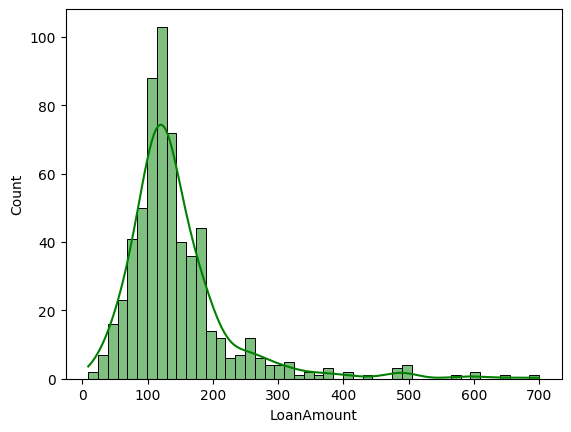

In [14]:
sns.histplot(x=df["LoanAmount"],kde=True,color="green")

In [15]:
df.shape

(614, 13)

##### Loan_Amount_Term (element data types is Numerical) ---- Null Values :-> 14

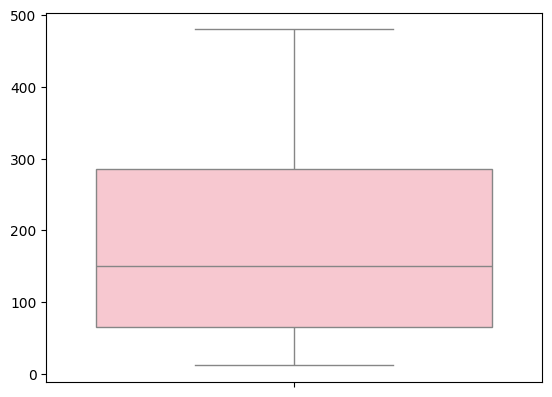

In [16]:
no_of_unique_value_in_loan_amount_term = df["Loan_Amount_Term"].unique()
len("no_of_unique_value_in_loan_amount_term")
sns.boxplot(data=no_of_unique_value_in_loan_amount_term,color="pink")
plt.show()

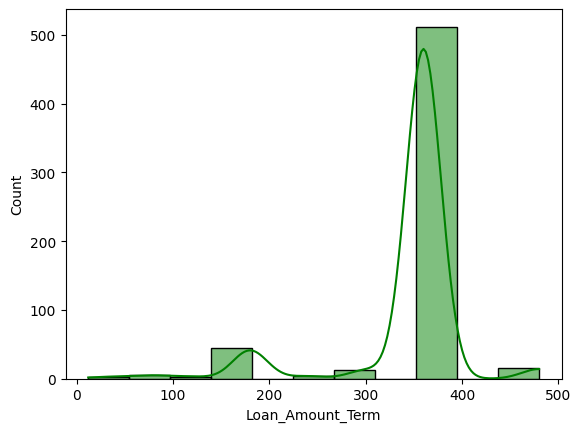

In [17]:
sns.histplot(data = df["Loan_Amount_Term"],kde=True,color="green")
plt.show()

In [18]:
print(f"Mean : {df['Loan_Amount_Term'].mean()}\nMedian : {df['Loan_Amount_Term'].median()} \nMaximum : {df['Loan_Amount_Term'].max()} \nMinimum : {df['Loan_Amount_Term'].min()} \nMode : {df['Loan_Amount_Term'].mode()}")

Mean : 342.0
Median : 360.0 
Maximum : 480.0 
Minimum : 12.0 
Mode : 0    360.0
Name: Loan_Amount_Term, dtype: float64


In [19]:
df["Loan_Amount_Term"].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
240.0,4
84.0,4
120.0,3
60.0,2
36.0,2


In [20]:
len("no_of_unique_value_in_loan_amount_term")

38

###### Decision 02 : In Loan_Amount_Term Feacture contain few unique value that is 38 so we can relace null value by mean value that is 342

In [21]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean())

In [22]:
df["Loan_Amount_Term"].isnull().sum()

0

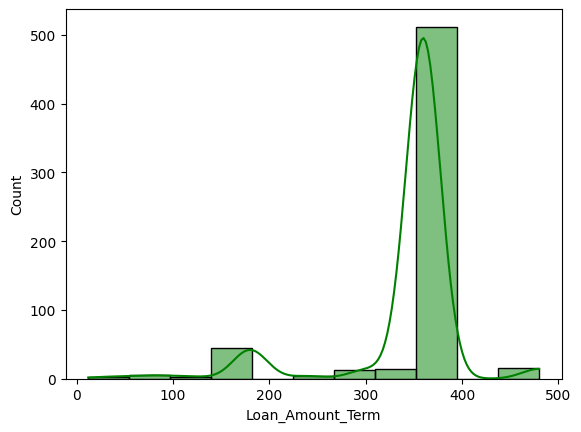

In [23]:
sns.histplot(data = df["Loan_Amount_Term"],kde=True,color="green")
plt.show()

##### Credit_History (element data types is Numerical) ---- Null Values :-> 50

In [33]:
df["Credit_History"].unique()
df["Credit_History"].value_counts()

,count
Credit_History,
1.0,525
0.0,89


###### Decision 03 : Credit_History that is catgorical feature but it store value in numerical form so we replace null value by mode value

In [34]:
# mode = df["Credit_History"].mode()
mode = 1

In [35]:
df["Credit_History"] = df["Credit_History"].fillna(mode)

In [36]:
df["Credit_History"].isnull().sum()

0

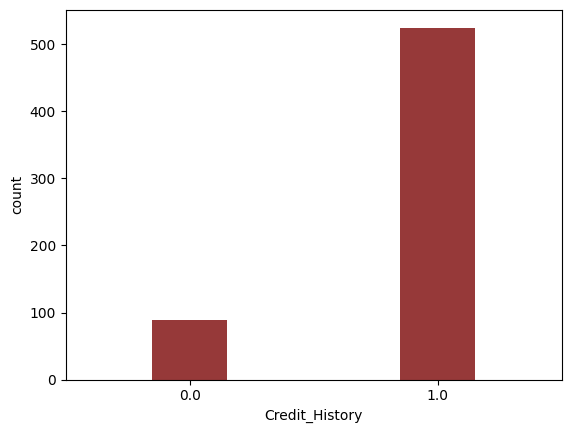

In [37]:
sns.countplot(x=df["Credit_History"],width=0.3,color="brown")
plt.show()

##### To Check / Test

In [38]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


#### Object Data Features

 ##### Gender (element data types is  *Object*)     ----	Null Values :-> 13
     


In [39]:
df["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

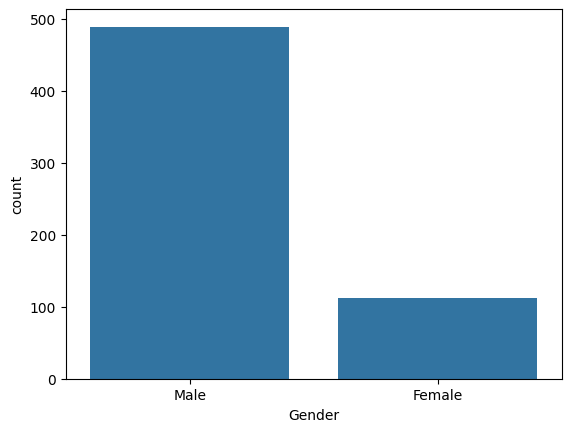

,count
Gender,
Male,489
Female,112


In [40]:
sns.countplot(x=df["Gender"])
plt.show()
df["Gender"].value_counts()

In [41]:
df["Gender"] = df["Gender"].fillna("Male")

In [42]:
df["Gender"].isnull().sum()

0

##### Married (element data types is *Object* )      ----	Null Values :-> 3
     

In [43]:
df["Married"].value_counts()

,count
Married,
Yes,398
No,213


In [44]:
df["Married"] = df["Married"].fillna("Yes")

In [45]:
df["Married"].isnull().sum()

0

##### Dependents (element data types is  *Object*)     ----	Null Values :-> 15
    

In [46]:
df["Dependents"].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

<Axes: xlabel='Dependents', ylabel='count'>

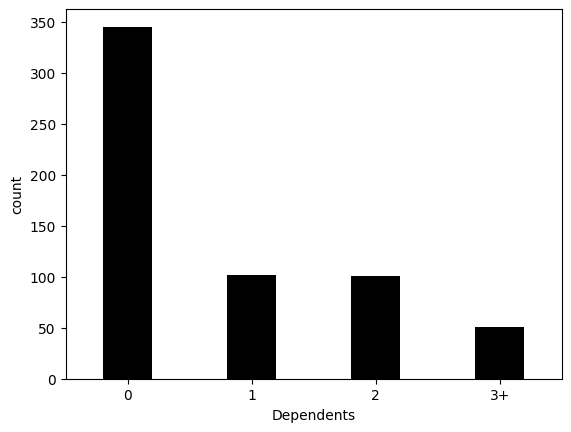

In [47]:
df["Dependents"].value_counts()
sns.countplot(x=df["Dependents"],color="k",width=0.4)

In [48]:
df["Dependents"] = df["Dependents"].fillna('0')

In [49]:
df["Dependents"].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [50]:
df["Dependents"].isnull().sum()

0

##### Self_Employed (element data types is  *Object*)      ----	Null Values :-> 32

In [51]:
df["Self_Employed"].unique()
df["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [52]:
df["Self_Employed"] = df["Self_Employed"].fillna('No')

In [53]:
df["Self_Employed"].isnull().sum()

0

In [54]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
